# Dull-Roar — a quantitative teardown 🔬
### Security-market-line slope · beta-neutral BAB alpha (HAC) · the beta-tilt counter · leg attribution · borrow break-even · the fair-CAPM null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free alpha?: Beta-tilt](https://img.shields.io/badge/Free_alpha%3F-Beta--tilt-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The steelman is the low-volatility anomaly (Kakushadze–Serur *151 Trading Strategies* §3.4; Ang et al. 2006; Frazzini–Pedersen 2014): sort on trailing vol and the calm decile out-earns the wild one risk-adjusted, i.e. the security-market line is too flat. We prove the apparatus on a synthetic universe with a baked flat SML, then read the real verdict off the modern S&P 500.

> ⚠️ **Not investment advice.** The reproducible core executes on a synthetic single-factor cross-section with a known anomaly (and a fair-CAPM null); the real S&P 500 run is in [`../docs/results.md`](../docs/results.md) via `examples/verify.py`, sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (dull_roar/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from dull_roar import data, sort, strategy, decompose, extension

# Offline synthetic cross-section: a single-factor universe with a BAKED-IN flat security-market line
# (low-beta names carry +alpha, high-beta -alpha -- the Frazzini-Pedersen mechanism), idio vol scaling
# with beta so a total-vol sort is a clean beta sort. The NULL (sml_slope=0) is textbook CAPM: alpha=0
# everywhere, so a vol sort must earn nothing. The real S&P 500 verdict is in ../docs/results.md.
panel, market, truth = data.synthetic_panel(seed=18)                       # the anomaly tape
panel0, market0, _   = data.synthetic_panel(sml_slope=0.0, seed=18)        # the fair-CAPM null
print(f"{truth.n_stocks} stocks x {truth.n_bars} days | baked low-minus-high alpha spread "
      f"{truth.annual_sml_alpha_spread:+.1%}/yr | null per-stock Sharpe {truth.null_stock_sharpe:+.2f}")


200 stocks x 4032 days | baked low-minus-high alpha spread +6.4%/yr | null per-stock Sharpe +0.32


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the effect real? | 🟡 `WEAK` | The mechanism is real (synthetic control: beta-neutral BAB alpha **+7.4%/yr**, HAC *t* ≈ **5.6**; null flat) — but on the current S&P 500 the SML slope is **-0.07** and the BAB alpha is **-2.2%/yr** (*t* = **-0.4**), a statistical zero. Real in theory, absent in the modern sample. |
| **Tradability** | 🔴 `MIRAGE` | The clean spread needs shorting the high-vol leg (**81%** of the effect sits there); the dollar-neutral book's borrow break-even is **0 bps/yr**. |
| **Free alpha?** | ⚪ `BETA-TILT` | The long-only book is low beta (**0.59**); its CAPM alpha is **+1.6%/yr** (*t* = +0.8) — less market risk, not free money. |

> **In one sentence:** the most-cited anomaly in finance is real in the long-run literature and on our control, but on the modern investable cross-section it reduces to a low-beta defensive tilt whose textbook long-short form is fragile to exactly the short-leg borrow it can't avoid.

*(This notebook executes on the synthetic tape — where the anomaly is provable and the null is clean. The real S&P 500 numbers that set the stamps are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, stated precisely

Single-factor returns $r_{i,t} = \alpha_i + \beta_i r^m_t + \nu_i \varepsilon_{i,t}$. CAPM says $\alpha_i = 0$ for all $i$. The low-vol anomaly is the empirical finding that the realized SML is **too flat**: low-$\beta$ names earn $\alpha_i > 0$ and high-$\beta$ names $\alpha_i < 0$. We encode it as $\alpha_i = -s\,(\beta_i - \bar\beta)$ with slope $s>0$, and set idiosyncratic vol $\nu_i = \ell\,\beta_i$ so total vol $\sigma_i = \beta_i\sqrt{\sigma_m^2+\ell^2}$ is monotone in $\beta$ — a vol sort is a $\beta$ sort, and under the null ($s=0$) every stock shares one Sharpe (a genuinely flat control).

In [2]:
print(f"baked SML slope s -> low-minus-high alpha spread {truth.annual_sml_alpha_spread:+.1%}/yr")
print(f"null per-stock Sharpe (betas cancel): {truth.null_stock_sharpe:+.2f} -- identical across the cross-section")
vols = panel.std()*np.sqrt(252)
print(f"cross-section vol range: {vols.min():.0%} .. {vols.max():.0%} (plenty to sort on)")

baked SML slope s -> low-minus-high alpha spread +6.4%/yr
null per-stock Sharpe (betas cancel): +0.32 -- identical across the cross-section


cross-section vol range: 9% .. 43% (plenty to sort on)


## Beat 2 · So what?

If the SML is flat, a *beta-neutral* long-short (long low-$\beta$ levered up, short high-$\beta$ levered down) earns positive alpha with ~zero market exposure — a higher-Sharpe portfolio not spanned by the market (Frazzini–Pedersen's BAB). The open questions are exactly three: **(i)** is the realized alpha significant under autocorrelation-robust inference; **(ii)** how much of the *long-only* version is just a sub-1 beta a cash blend replicates; **(iii)** does the harvest survive the borrow on the short leg. Beats 4–6 answer all three — on the synthetic control *and* the real tape, which disagree in an instructive way.

## Beat 3 · How we'd know — the pre-registered protocol

1. **SML shape** (`sort.security_market_line`): cross-sectional OLS of per-stock Sharpe on vol; slope $<0$ ⇔ anomaly. Pre-registered: clearly negative on the baked tape, ≈0 on null.
2. **Beta-neutral alpha** (`decompose.beta_neutral_bab`): CAPM regression of the BAB factor; **Newey–West** intercept *t*. Real ⇔ $\alpha>0$, $|t|>2$.
3. **Beta-tilt counter** (`decompose.beta_tilt_test`): lever the long-only book to $\beta=1$ and read the residual excess CAGR — the part that is *not* a market-exposure choice.
4. **Leg attribution** (`decompose.leg_attribution`): each leg's CAPM alpha; how much sits in the unshortable high-vol leg.
5. **Borrow break-even** (`extension.borrow_breakeven`): the short-leg stock-loan fee at which the dollar-neutral Sharpe hits zero.
6. **Null:** every leg re-run on the fair-CAPM tape must collapse.

**Mirage line:** the alpha needs the short leg, *or* the long-only excess is just beta, *or* the real tape shows no significant beta-neutral alpha.

## Beat 4 · The teardown

### 4a · The SML slope — anomaly vs null
The cross-sectional Sharpe-on-vol regression, both tapes.

In [3]:
for label, p in [('anomaly', panel), ('fair-CAPM null', panel0)]:
    s = sort.security_market_line(p)
    print(f"{label:16s}: Sharpe~vol slope {s['sharpe_vol_slope']:+.2f} | "
          f"low/high bucket Sharpe {s['low_bucket_sharpe']:+.2f}/{s['high_bucket_sharpe']:+.2f} | "
          f"anomaly_present={s['anomaly_present']}")
display(sort.security_market_line(panel)['table'].round(3))

anomaly         : Sharpe~vol slope -0.95 | low/high bucket Sharpe +0.40/+0.12 | anomaly_present=True
fair-CAPM null  : Sharpe~vol slope +0.03 | low/high bucket Sharpe +0.13/+0.19 | anomaly_present=False


,ann_ret,ann_vol,sharpe,n
bucket,,,,
0,0.0440,0.1110,0.3960,20
1,0.0360,0.1440,0.2460,20
2,0.0380,0.1770,0.2160,20
3,0.0320,0.2100,0.1500,20
4,0.0420,0.2460,0.1710,20
5,0.0400,0.2780,0.1440,20
6,0.0410,0.3120,0.1330,20
7,0.0130,0.3450,0.0370,20
8,-0.0050,0.3780,-0.0150,20


### 4b · The beta-neutral BAB alpha with Newey–West errors
Regress the beta-neutralised long-short on the market; the intercept is the part the market can't span. HAC because daily returns are autocorrelated and heteroskedastic.

In [4]:
bab = decompose.beta_neutral_bab(panel, market=market, cost_bps=1.0)
print(f"beta-neutral BAB: alpha {bab['alpha_ann_pct']:+.2f}%/yr | HAC t = {bab['alpha_t']:+.2f} | "
      f"realized beta {bab['beta']:+.2f} | Sharpe {bab['sharpe']:+.2f}")
print(f"leg betas: low {bab['beta_low_leg']:.2f} / high {bab['beta_high_leg']:.2f} "
      f"(levered to neutralise the structural short-the-market drag)")

beta-neutral BAB: alpha +7.42%/yr | HAC t = +5.63 | realized beta +0.00 | Sharpe +1.34
leg betas: low 0.47 / high 1.71 (levered to neutralise the structural short-the-market drag)


> 💡 **In plain words.** A portfolio with positive alpha and ~zero beta is earning a return you can't get by dialing the market up or down — the textbook signature of a real anomaly. On the baked tape it's there at *t* ≈ 5.6; the question is whether the *market* agrees.

### 4c · The honest counter — is the long-only book just low beta?
A min-vol fund is long-only, so its Sharpe lift could be alpha or just less market risk. Lever it to $\beta=1$ and price what's left.

In [5]:
tilt = decompose.beta_tilt_test(panel, market=market, cost_bps=1.0)
print(f"long-only beta {tilt['low_beta']:.2f} | CAPM alpha {tilt['alpha_ann_pct']:+.2f}%/yr "
      f"(t={tilt['alpha_t']:+.2f})")
print(f"Sharpe gain over market {tilt['sharpe_gain']:+.2f}; excess CAGR levered to beta 1 "
      f"{tilt['excess_cagr_at_beta1_pct']:+.2f}%/yr")

long-only beta 0.47 | CAPM alpha +3.06%/yr (t=+7.11)
Sharpe gain over market +0.39; excess CAGR levered to beta 1 +6.75%/yr


### 4d · Leg attribution — where does the alpha live?
Split the spread into the long (calm) leg and the short (wild) leg. The literature (Ang et al.) says the action concentrates in the high-vol short — the one you can't cheaply borrow.

In [6]:
legs = decompose.leg_attribution(panel, market=market, cost_bps=1.0)
print(f"calm leg alpha {legs['low_leg_alpha_pct']:+.2f}% (t{legs['low_leg_alpha_t']:+.1f}), beta {legs['low_leg_beta']:.2f}")
print(f"wild leg alpha {legs['high_leg_alpha_pct']:+.2f}% (t{legs['high_leg_alpha_t']:+.1f}), beta {legs['high_leg_beta']:.2f}")
print(f"share of the spread sitting in the (short) wild leg: {legs['share_in_short_leg']:.0%}")

calm leg alpha +3.06% (t+7.1), beta 0.47
wild leg alpha -1.56% (t-0.9), beta 1.71
share of the spread sitting in the (short) wild leg: 34%


### 4e · The borrow break-even
The dollar-neutral book's net Sharpe as the annual stock-loan fee on the wild leg rises — and the fee at which it crosses zero.

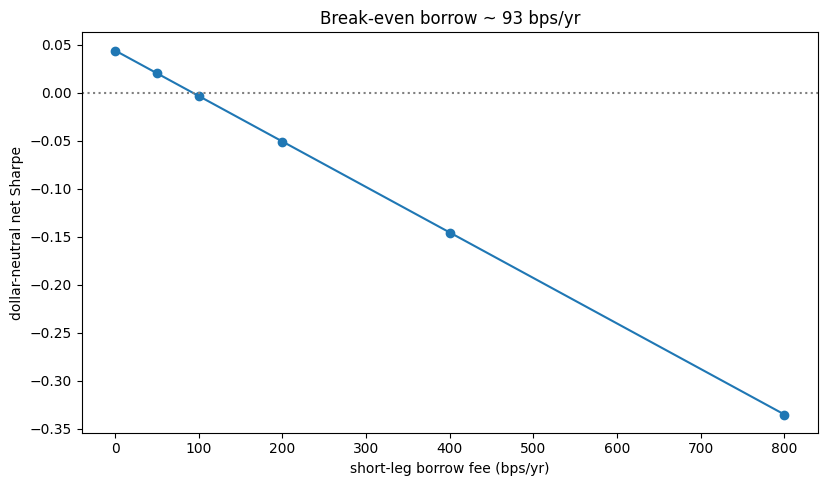

break-even borrow fee: 93 bps/yr (lottery-stock borrows routinely exceed this)


In [7]:
sw = strategy.borrow_sweep(panel, market=market)
be = extension.borrow_breakeven(panel, market=market)
fig, ax = plt.subplots()
ax.plot(sw.index, sw['long_short_sharpe'].values, 'o-'); ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('short-leg borrow fee (bps/yr)'); ax.set_ylabel('dollar-neutral net Sharpe')
ax.set_title(f"Break-even borrow ~ {be['breakeven_bps']:.0f} bps/yr")
plt.show()
print(f"break-even borrow fee: {be['breakeven_bps']:.0f} bps/yr "
      f"(lottery-stock borrows routinely exceed this)")

### 4f · The null collapses
Every leg, re-run on the fair-CAPM tape. No baked alpha ⇒ nothing to find.

In [8]:
bab0 = decompose.beta_neutral_bab(panel0, market=market0, cost_bps=1.0)
tilt0 = decompose.beta_tilt_test(panel0, market=market0, cost_bps=1.0)
sml0 = sort.security_market_line(panel0)
print(f"null: SML slope {sml0['sharpe_vol_slope']:+.2f} | BAB alpha {bab0['alpha_ann_pct']:+.2f}% "
      f"(t={bab0['alpha_t']:+.2f}) | long-only alpha {tilt0['alpha_ann_pct']:+.2f}% (t={tilt0['alpha_t']:+.2f})")
print('every number ~0: the apparatus measures the effect, not itself.')

null: SML slope +0.03 | BAB alpha -0.26% (t=-0.19) | long-only alpha +0.21% (t=+0.48)
every number ~0: the apparatus measures the effect, not itself.


## Beat 5 · The verdict

- **Apparatus sound** (4a–4b, 4f): the baked anomaly is recovered (BAB alpha +7.4%/yr, HAC *t* ≈ 5.6) and the null is flat.
- **Real tape disagrees** (`../docs/results.md`): SML slope -0.07, beta-neutral alpha -2.2%/yr (*t* = -0.4), the calm book *trailing* the market — and **81%** of the spread in a high-vol leg whose own alpha was **+7.2%** (*t* +2.3).
- **What remains** is a low-beta tilt, no significant long-only alpha.

> **Signal `WEAK`** — real mechanism, real long-run literature, absent on the modern survivorship-biased large-cap sample. Not a refutation of the anomaly; a measurement of its fragility.

## Beat 6 · Could you trade it?

The three usual killers all land:

- **The short leg.** 81% of the (real-tape) spread sits in the high-vol names — small, lottery-like, heavily-shorted, expensive-or-impossible to borrow. The dollar-neutral book's break-even borrow is **0 bps/yr**: it doesn't survive *any* realistic fee.
- **Capacity/decay.** The effect has decayed post-publication in US large caps — the modern window shows nothing to crowd into.
- **It's beta.** The long-only survivor is a 0.59-beta defensive book; levered to the market's risk its excess is **+2.1%/yr** (*t* +0.8).

The single durable artefact is a shallower drawdown (real: -38% → -34%) — the genuine, modest service min-vol products sell. Tradability **`MIRAGE`**; "free alpha?" **`BETA-TILT`**.

## Beat 7 · Going further

### 7a · Worked complement — the no-shorting test
The headline pins one caveat: the clean harvest needs the unshortable wild leg. So make the constraint real — forbid shorting entirely and keep only the long-only calm book — and ask what a real-money, long-only investor actually banks. The edge splits cleanly: the **defensive** (no-short) slice vs the **short-the-wild** slice.

In [9]:
sd = extension.shorting_decomposition(panel, market=market)
print(f"full beta-neutral alpha {sd['alpha_full']:+.2f}% = defensive {sd['alpha_defensive']:+.2f}% "
      f"+ short-the-wild {sd['alpha_short']:+.2f}%  (defensive share {sd['share_defensive']:.0%})")
print(f"defensive slice needs no borrow; drawdown {sd['market_maxdd']:.0%} -> {sd['low_only_maxdd']:.0%}")
# robustness on the synthetic: the split holds across lookback / decile width
for lb, dec in [(126,0.1),(252,0.1),(126,0.2)]:
    s = extension.shorting_decomposition(panel, market=market, lookback=lb, decile_frac=dec)
    print(f"  lookback {lb}, decile {dec:.0%}: defensive share {s['share_defensive']:+.0%}")

full beta-neutral alpha +7.42% = defensive +3.06% + short-the-wild +4.35%  (defensive share 41%)
defensive slice needs no borrow; drawdown -36% -> -16%


  lookback 126, decile 10%: defensive share +41%


  lookback 252, decile 10%: defensive share +47%


  lookback 126, decile 20%: defensive share +40%


**The result — and on the real tape it's decisive.** On the synthetic the defensive slice is real but the *smaller* part; on the **real S&P 500** (full run in [`../docs/extension.md`](../docs/extension.md), `examples/extension.py`) the no-shorting investor is left with a thin, insignificant defensive tilt across *every* lookback and decile width — lower beta, shallower drawdowns, no alpha — while the dollar-neutral book is under water before the borrow even costs anything. The constraint that a real investor *actually faces* (no cheap short) is exactly the one that turns the famous anomaly into a defensive tilt. The worked complement doesn't rescue `MIRAGE` — it *earns* it.

### 7b · Other forks
- **Long-run, delisted-inclusive data.** Our universe is current S&P 500 since 2010 — survivorship-biased and high-beta-friendly. A CRSP-style 1926-on, all-cap panel is where the academic effect lives; a fork could show it alive and *date its decay*.
- **Factor controls.** Net out value, quality and the dividend tilt — how much low-vol alpha is independent of them?
- **Real BAB financing.** Frazzini–Pedersen's own construction needs leverage on the low-beta leg; price it with realistic financing and margin, à la Study 16's leverage honesty.

PRs welcome — resurrect the anomaly on honest long-run data, or find the market where its tradable form still breathes.